In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("src"))

import preprocessing

# Učitavanje podataka
df = pd.read_csv("data/podaci.csv")
print(f"\nDimenzija tabele: {df.shape}")

# Preprocesiranje
df_processed = preprocessing.preprocess(df)

print(f"\nNova dimenzija tabele: {df_processed.shape}")
print("\nPrvih 5 redova enkodiranih podataka:")
display(df_processed.head())


Dimenzija tabele: (3000, 25)

Nema duplikata.

Nova dimenzija tabele: (3000, 28)

Prvih 5 redova enkodiranih podataka:


,ID,Name,Age,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level,Gender_Male,Gender_Other,Phone_Usage_Purpose_Education,Phone_Usage_Purpose_Gaming,Phone_Usage_Purpose_Other,Phone_Usage_Purpose_Social Media
0,1,Shannon Francis,13,9,4.0,6.1,78,5,0.1,10,...,1.2,4,8.7,10.0,False,False,False,False,False,False
1,2,Scott Rodriguez,17,7,5.5,6.5,70,5,0.0,3,...,1.8,2,5.3,10.0,False,False,False,False,False,False
2,3,Adrian Knox,13,11,5.8,5.5,93,8,0.8,2,...,0.4,6,5.7,9.2,False,True,True,False,False,False
3,4,Brittany Hamilton,18,12,3.1,3.9,78,8,1.6,9,...,0.8,8,3.0,9.8,False,False,False,False,False,True
4,5,Steven Smith,14,9,2.5,6.7,56,4,1.1,1,...,1.1,10,3.7,8.6,False,True,False,True,False,False


In [6]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import models

X = df_processed.drop(columns=['Addiction_Level', 'ID', 'Name'], errors='ignore')
y = df_processed['Addiction_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. K-Fold validacija
models.validate_model_with_cv(LinearRegression(), X_train, y_train, use_weights=False)
models.validate_model_with_cv(LinearRegression(), X_train, y_train, use_weights=True)

models.validate_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=False)
models.validate_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=True)

# 2. Finalni model za segmentaciju
results_standard = models.get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=False)
results_weighted = models.get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=True)


===== LinearRegression (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.6765
CV Prosečan RMSE (Trening): 0.8428
CV Prosečan R2 Score (Trening): 0.7303

===== LinearRegression (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.7154
CV Prosečan RMSE (Trening): 0.9126
CV Prosečan R2 Score (Trening): 0.6821

===== XGBRegressor (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.3629
CV Prosečan RMSE (Trening): 0.5331
CV Prosečan R2 Score (Trening): 0.8918

===== XGBRegressor (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.3832
CV Prosečan RMSE (Trening): 0.5533
CV Prosečan R2 Score (Trening): 0.8834

===== XGBRegressor (Finalni Standard) =====
Finalni MAE (Test): 0.3500
Finalni RMSE (Test): 0.5103
Finalni R2 Score (Test): 0.8943

===== XGBRegressor (Finalni Weighted) =====
Finalni MAE (Test): 0.3515
Finalni RMSE (Test): 0.5006
Finalni R2 Score (Test): 0.8983


Broj uzoraka po segmentima:
1-6: 62
7-8: 102
9-10: 574

MAE po segmentima:
MAE (1-6): 0.7435084427556683
MAE (7-8): 0.5436938772014543
MAE (9-10): 0.24000872120209274

RMSE po segmentima:
RMSE (1-6): 0.9356939311451374
RMSE (7-8): 0.6466302121015258
RMSE (9-10): 0.36612074518020055


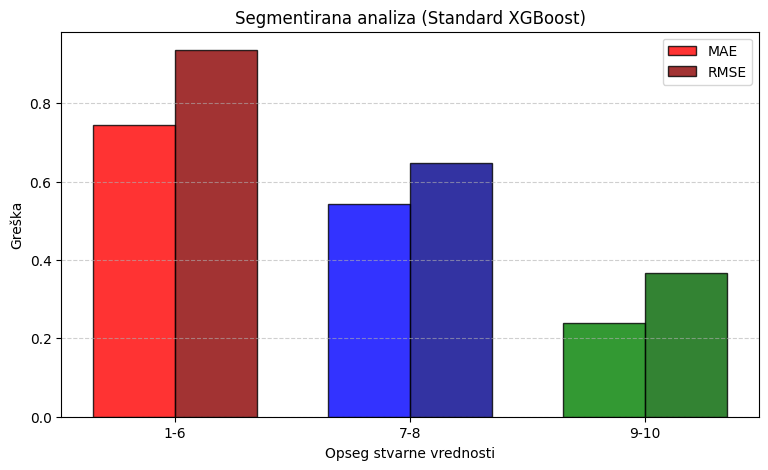

Broj uzoraka po segmentima:
1-6: 62
7-8: 102
9-10: 574

MAE po segmentima:
MAE (1-6): 0.7577198720747423
MAE (7-8): 0.4427216324151729
MAE (9-10): 0.25872426996663056

RMSE po segmentima:
RMSE (1-6): 0.9343490251123433
RMSE (7-8): 0.5634113484699871
RMSE (9-10): 0.37914790271598825


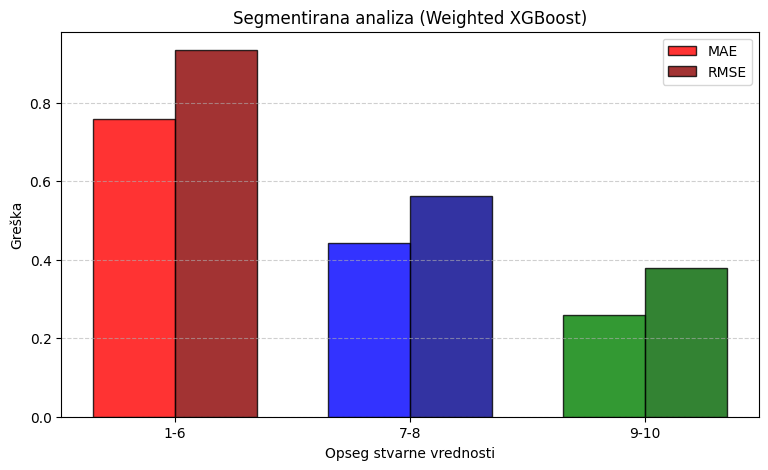

In [7]:
def plot_segmented_analysis(results_df, title="Segmentirana analiza"):
    """
    Segmentirana analiza MAE i RMSE po klasama.
    Segmenti:
        low: 1-6
        mid: 7-8
        high: 9-10
    """
    # Definisanje segmenata
    low = results_df[(results_df["true"] >= 1) & (results_df["true"] <= 6)]
    mid = results_df[(results_df["true"] >= 7) & (results_df["true"] <= 8)]
    high = results_df[(results_df["true"] >= 9) & (results_df["true"] <= 10)]

    # Broj uzoraka po segmentu
    counts = [len(low), len(mid), len(high)]
    print("Broj uzoraka po segmentima:")
    print("1-6:", counts[0])
    print("7-8:", counts[1])
    print("9-10:", counts[2])

    # MAE i RMSE po segmentu
    mae_values = [
        mean_absolute_error(low["true"], low["pred"]),
        mean_absolute_error(mid["true"], mid["pred"]),
        mean_absolute_error(high["true"], high["pred"])
    ]
    rmse_values = [
        np.sqrt(mean_squared_error(low["true"], low["pred"])),
        np.sqrt(mean_squared_error(mid["true"], mid["pred"])),
        np.sqrt(mean_squared_error(high["true"], high["pred"]))
    ]
    print("\nMAE po segmentima:")
    print("MAE (1-6):", mae_values[0])
    print("MAE (7-8):", mae_values[1])
    print("MAE (9-10):", mae_values[2])

    print("\nRMSE po segmentima:")
    print("RMSE (1-6):", rmse_values[0])
    print("RMSE (7-8):", rmse_values[1])
    print("RMSE (9-10):", rmse_values[2])

    # Bar plot za MAE i RMSE
    groups = ["1-6", "7-8", "9-10"]
    colors_mae = ['red', 'blue', 'green']
    colors_rmse = ['darkred', 'darkblue', 'darkgreen']

    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9,5))
    rects1 = ax.bar(x - width/2, mae_values, width, label='MAE', color=colors_mae, edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x + width/2, rmse_values, width, label='RMSE', color=colors_rmse, edgecolor='black', alpha=0.8)

    ax.set_xlabel("Opseg stvarne vrednosti")
    ax.set_ylabel("Greška")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.show()


# Standardni XGBoost
plot_segmented_analysis(results_standard, title="Segmentirana analiza (Standard XGBoost)")

# Weighted XGBoost
plot_segmented_analysis(results_weighted, title="Segmentirana analiza (Weighted XGBoost)")


MAE po segmentima (Standard XGBoost): [0.7435084427556683, 0.5436938772014543, 0.24000872120209274]
MAE po segmentima (Weighted XGBoost): [0.7577198720747423, 0.4427216324151729, 0.25872426996663056]


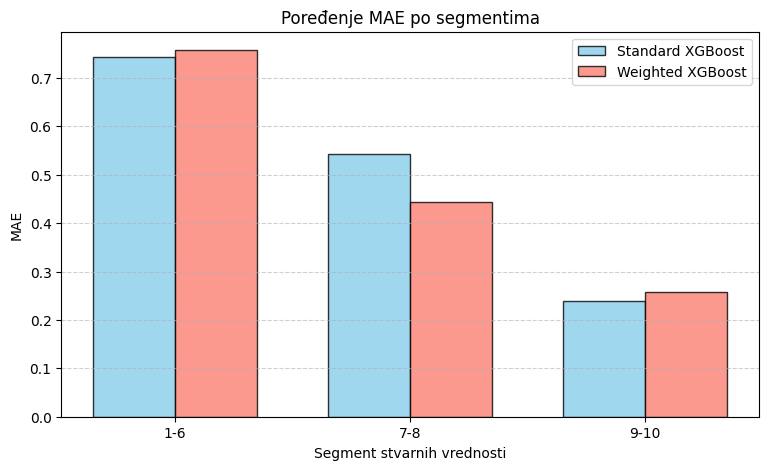

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import numpy as np

def compare_segmented_mae(results1, results2, labels=("Standard", "Weighted"), title="Poređenje MAE po segmentima"):
    """
    Upoređuje MAE po segmentima za dva seta rezultata.
    results1, results2: DataFrame sa kolonama 'true' i 'pred'
    labels: imena koja će se koristiti u legendi
    """
    segments = [
        ("1-6", 1, 6),
        ("7-8", 7, 8),
        ("9-10", 9, 10)
    ]

    mae1 = []
    mae2 = []

    for seg_label, seg_min, seg_max in segments:
        seg1 = results1[(results1["true"] >= seg_min) & (results1["true"] <= seg_max)]
        seg2 = results2[(results2["true"] >= seg_min) & (results2["true"] <= seg_max)]

        mae1.append(mean_absolute_error(seg1["true"], seg1["pred"]))
        mae2.append(mean_absolute_error(seg2["true"], seg2["pred"]))

    x = np.arange(len(segments))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9,5))
    rects1 = ax.bar(x - width/2, mae1, width, label=labels[0], color='skyblue', edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x + width/2, mae2, width, label=labels[1], color='salmon', edgecolor='black', alpha=0.8)

    ax.set_xlabel("Segment stvarnih vrednosti")
    ax.set_ylabel("MAE")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([seg[0] for seg in segments])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    print(f"\nMAE po segmentima ({labels[0]}): {mae1}")
    print(f"MAE po segmentima ({labels[1]}): {mae2}")

    plt.show()

# poredjenje weighted i standard
compare_segmented_mae(results_standard, results_weighted, labels=("Standard XGBoost", "Weighted XGBoost"))